# Preprocessing Notebook
This is a placeholder notebook for Silver layer.

# Silver Layer – Preprocessing & Feature Analysis

This notebook follows the **complete Silver Layer** data science workflow:

1. **Merging Data & Preparing for Analysis** – Table joins, null handling, churn target creation
2. **Exploratory Data Analysis (EDA) & Visualization** – Distributions, box plots, outliers, correlation heatmap
3. **Hypothesis Testing & Feature Selection** – Statistical tests (Chi-Square, ANOVA, Permutation, Normality, Homoscedasticity, Correlation, VIF)
4. **Creating Churn Categories** – Numeric target encoding (0 = No Churn, 1 = Partial Churn, 2 = Full Churn)
5. **Feature Selection Summary** – Final encoded, proven features for the Gold layer model

---
# 1. Importing the Necessary Modules

In [1]:
import pandas as pd
import numpy as np
import importlib.util
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Importing the Necessary File Modules
Using `importlib.util` to add paths dynamically to import the necessary modules from `src/`

In [2]:
# Define paths to all required modules
module_paths = {
    'load_intermediate_data': '../../src/data/load_intermediate_data.py',
    'create_churn_categories': '../../src/features/create_churn_categories.py',
    'merge_data': '../../src/features/merge_data.py',
    'outlier_detection': '../../src/features/outlier_detection.py',
    'hypothesis_1_chi_square': '../../src/features/hypothesis_1_chi_square.py',
    'hypothesis_2_anova': '../../src/features/hypothesis_2_anova.py',
    'hypothesis_3_permutation_test': '../../src/features/hypothesis_3_permutation_test.py',
    'hypothesis_4_normality': '../../src/features/hypothesis_4_normality.py',
    'hypothesis_5_homoscedasticity': '../../src/features/hypothesis_5_homoscedasticity.py',
    'hypothesis_6_correlation': '../../src/features/hypothesis_6_correlation.py',
    'hypothesis_7_multicollinearity': '../../src/features/hypothesis_7_multicollinearity.py',
    'feature_selection_summary': '../../src/features/feature_selection_summary.py',
    'eda_plots': '../../src/visualization/eda_plots.py',
    'normality_plots': '../../src/visualization/normality_plots.py',
}

# Dynamically import all modules
loaded_modules = {}
for name, path in module_paths.items():
    spec = importlib.util.spec_from_file_location(f'src.{name}', path)
    if spec is None:
        raise ImportError(f'Could not load module from {path}')
    module = importlib.util.module_from_spec(spec)
    sys.modules[f'src.{name}'] = module
    spec.loader.exec_module(module)
    loaded_modules[name] = module

# Assign readable aliases
load_module = loaded_modules['load_intermediate_data']
churn_module = loaded_modules['create_churn_categories']
merge_module = loaded_modules['merge_data']
outlier_module = loaded_modules['outlier_detection']
hypo_1_module = loaded_modules['hypothesis_1_chi_square']
hypo_2_module = loaded_modules['hypothesis_2_anova']
hypo_3_module = loaded_modules['hypothesis_3_permutation_test']
hypo_4_module = loaded_modules['hypothesis_4_normality']
hypo_5_module = loaded_modules['hypothesis_5_homoscedasticity']
hypo_6_module = loaded_modules['hypothesis_6_correlation']
hypo_7_module = loaded_modules['hypothesis_7_multicollinearity']
summary_module = loaded_modules['feature_selection_summary']
eda_module = loaded_modules['eda_plots']
norm_plot_module = loaded_modules['normality_plots']

print('All modules loaded successfully!')

All modules loaded successfully!


---
# 2. Loading the Intermediate Data
Loading the cleaned datasets from the Bronze layer output (`data/02_intermediate/`)

In [3]:
loaded_data = load_module.LoadIntermediateData()
print('Data loaded successfully using LoadIntermediateData module')

Intermediate data loaded successfully!
Data loaded successfully using LoadIntermediateData module


In [4]:
cleaned_retention = loaded_data.cleaned_retention
cleaned_bob = loaded_data.cleaned_bob
y = loaded_data.target_y

### Display data info and first few rows

In [5]:
print('Cleaned Retention - Data Info:')
print(f'Shape: {cleaned_retention.shape}')
print(f'{cleaned_retention.info()}')
print(f'Null counts:\n{cleaned_retention.isnull().sum()}')
print('First 5 rows:')
display(cleaned_retention.head())

print('\nCleaned BoB - Data Info:')
print(f'Shape: {cleaned_bob.shape}')
print(f'{cleaned_bob.info()}')
print(f'Null counts:\n{cleaned_bob.isnull().sum()}')
print('First 5 rows:')
display(cleaned_bob.head())

print('\nTarget Data - Data Info:')
print(f'Shape: {y.shape}')
print(f'Null counts:\n{y.isnull().sum()}')
print('First 5 rows:')
display(y.head())

Cleaned Retention - Data Info:
Shape: (48971, 9)
<class 'pandas.DataFrame'>
RangeIndex: 48971 entries, 0 to 48970
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   case_id                  48971 non-null  str  
 1   customer_account_number  45842 non-null  str  
 2   current_status           48971 non-null  str  
 3   resolution_status        48971 non-null  str  
 4   branch                   45548 non-null  str  
 5   customer_tier            29841 non-null  str  
 6   case_type                48971 non-null  str  
 7   pull_type                26920 non-null  str  
 8   country                  48971 non-null  str  
dtypes: str(9)
memory usage: 3.4 MB
None
Null counts:
case_id                        0
customer_account_number     3129
current_status                 0
resolution_status              0
branch                      3423
customer_tier              19130
case_type                     

,case_id,customer_account_number,current_status,resolution_status,branch,customer_tier,case_type,pull_type,country
0,CAS-32058-P6H2Z7,NaN,In Progress,OPEN - In Progress,NaN,NaN,Risk,Full,United Kingdom
1,CAS-32054-V6L5K1,NaN,In Progress,OPEN - In Progress,NaN,NaN,Risk,Full,United Kingdom
2,CAS-42090-M1V1V7,NaN,In Progress,OPEN - In Progress,NaN,NaN,Risk,Full,United Kingdom
3,CAS-30365-C0V8P9,NaN,In Progress,OPEN - In Progress,NaN,NaN,Risk,Full,United Kingdom
4,CAS-30366-Z3S1G3,NaN,In Progress,OPEN - In Progress,NaN,NaN,Risk,Full,United Kingdom



Cleaned BoB - Data Info:
Shape: (131622, 10)
<class 'pandas.DataFrame'>
RangeIndex: 131622 entries, 0 to 131621
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   account_number        131612 non-null  str    
 1   agreement_number      131612 non-null  str    
 2   system_status         131612 non-null  str    
 3   agreement_start_date  131612 non-null  str    
 4   agreement_end_date    131612 non-null  str    
 5   renewal_type          131612 non-null  str    
 6   branch                131612 non-null  str    
 7   product_bob           131621 non-null  float64
 8   fee_bob               131621 non-null  float64
 9   total_bob             131621 non-null  float64
dtypes: float64(3), str(7)
memory usage: 10.0 MB
None
Null counts:
account_number          10
agreement_number        10
system_status           10
agreement_start_date    10
agreement_end_date      10
renewal_type            10
b

,account_number,agreement_number,system_status,agreement_start_date,agreement_end_date,renewal_type,branch,product_bob,fee_bob,total_bob
0,UK02-CGBA029544-L,GBC4019041-Machine Services-327311,Active,2025-03-17 00:00:00,2026-03-16 00:00:00,Automatic Renewal,Elmswell,117745.68,0.0,117745.68
1,UK02-CGBA029544-L,GBC4021962-Machine Services-332280,Active,2025-04-14 00:00:00,2028-04-13 00:00:00,Automatic Renewal,Elmswell,105967.68,0.0,105967.68
2,UK02-CGBA029544-L,GBC4021962-Machine Services-332282,Active,2025-04-14 00:00:00,2028-04-13 00:00:00,Automatic Renewal,Elmswell,105967.68,0.0,105967.68
3,UK02-CGBA124601-L,GBC4000950-Auto waste,Active,2022-06-24 00:00:00,2026-06-23 00:00:00,Automatic Renewal,Lisburn,92242.56,0.0,92242.56
4,UK02-CGBA034502-L,GBC3028394-Chemistry,Active,2024-11-04 00:00:00,2025-11-03 00:00:00,Automatic Renewal,Lisburn,83206.92,0.0,83206.92



Target Data - Data Info:
Shape: (85411, 3)
Null counts:
Case ID                       0
Customer Account Number    7462
Resolution Status             0
dtype: int64
First 5 rows:


,Case ID,Customer Account Number,Resolution Status
0,CAS-32058-P6H2Z7,NaN,OPEN - In Progress
1,CAS-32054-V6L5K1,NaN,OPEN - In Progress
2,CAS-32054-V6L5K1,NaN,OPEN - In Progress
3,CAS-42090-M1V1V7,NaN,OPEN - In Progress
4,CAS-42090-M1V1V7,NaN,OPEN - In Progress


---
# 3. Merging Data and Preparing for Analysis

**Steps performed here:**
- Create churn categories from BoB agreement data (our target variable)
- Aggregate Retention and BoB data at the account level
- Merge all three into a single analysis-ready dataset
- Handle remaining null values via imputation

### 3.1 Creating Churn Categories

Creating a 3-level churn classification from the BoB data:
- **No Churn (0)**: Customer maintains all active agreements
- **Partial Churn (1)**: Customer loses some agreements but keeps others (agreement-level churn)
- **Full Churn (2)**: Customer loses ALL agreements (customer-level churn)

In [6]:
# Create churn categories using the reusable module
churn_creator = churn_module.CreateChurnCategories(cleaned_bob)
account_churn = churn_creator.create_churn_categories()

print('\nFirst 10 rows of account churn data:')
display(account_churn.head(10))

Creating Churn Categories...
Account-level churn aggregation created!
Total unique accounts: 23772
Churn distribution:
churn_category
No Churn         11181
Full Churn        6789
Partial Churn     5802
Name: count, dtype: int64
Churn categories breakdown (%):
churn_category
No Churn         47.034326
Full Churn       28.558809
Partial Churn    24.406865
Name: proportion, dtype: float64

First 10 rows of account churn data:


,total_agreements,active_agreements,lost_agreements,churn_category
account_number,,,,
GBA221737,1,1,0,No Churn
UK02-000167723,2,2,0,No Churn
UK02-000167746,1,1,0,No Churn
UK02-000167747,1,1,0,No Churn
UK02-000167753,3,3,0,No Churn
UK02-000167754,2,2,0,No Churn
UK02-000167757,2,2,0,No Churn
UK02-000167760,2,2,0,No Churn
UK02-000167763,4,4,0,No Churn


### 3.2 Merging Retention + BoB + Churn Data

Joining the three datasets on `account_number` to create a single analysis dataset with features and the target variable.

In [7]:
# Merge all data using the reusable module
data_merger = merge_module.MergeData(account_churn, cleaned_retention, cleaned_bob)
analysis_df = data_merger.merge_and_prepare_data()

print('\nFinal analysis dataset info:')
print(f'Shape: {analysis_df.shape}')
print(f'Null counts:\n{analysis_df.isnull().sum()}')
print('\nFirst 5 rows:')
display(analysis_df.head())

Merging and Preparing Data for Analysis...
Available retention columns: ['case_id', 'customer_account_number', 'current_status', 'resolution_status', 'branch', 'customer_tier', 'case_type', 'pull_type', 'country']
Final analysis dataset shape: (23772, 16)
Analysis dataset columns: ['account_number', 'total_agreements', 'active_agreements', 'lost_agreements', 'churn_category', 'retention_customer_tier', 'retention_case_type', 'retention_pull_type', 'retention_current_status', 'retention_resolution_status', 'retention_country', 'main_product_bob', 'avg_fee_bob', 'total_revenue_bob', 'renewal_type', 'branch_bob']

Final analysis dataset info:
Shape: (23772, 16)
Null counts:
account_number                     0
total_agreements                   0
active_agreements                  0
lost_agreements                    0
churn_category                     0
retention_customer_tier        18589
retention_case_type            18144
retention_pull_type            19979
retention_current_status

,account_number,total_agreements,active_agreements,lost_agreements,churn_category,retention_customer_tier,retention_case_type,retention_pull_type,retention_current_status,retention_resolution_status,retention_country,main_product_bob,avg_fee_bob,total_revenue_bob,renewal_type,branch_bob
0,GBA221737,1,1,0,No Churn,NaN,NaN,NaN,NaN,NaN,NaN,8680.10,0.00,8680.10,Automatic Renewal,Elmswell
1,UK02-000167723,2,2,0,No Churn,NaN,NaN,NaN,NaN,NaN,NaN,1202.00,0.00,3616.75,Automatic Renewal,Maidstone
2,UK02-000167746,1,1,0,No Churn,NaN,NaN,NaN,NaN,NaN,NaN,2840.03,159.96,2999.99,Automatic Renewal,Cardiff
3,UK02-000167747,1,1,0,No Churn,NaN,NaN,NaN,NaN,NaN,NaN,2540.14,0.00,2540.14,Automatic Renewal,Chester
4,UK02-000167753,3,3,0,No Churn,NaN,NaN,NaN,NaN,NaN,NaN,4334.27,198.32,13952.74,Automatic Renewal,Exeter


### 3.3 Handling Remaining Null Values (Final Imputation)

After the merge, some accounts may not have matching Retention records. We handle these remaining nulls.

In [8]:
# Check null counts after merge
null_summary = analysis_df.isnull().sum()
null_pct = (analysis_df.isnull().sum() / len(analysis_df) * 100).round(2)
null_df = pd.DataFrame({'Null_Count': null_summary, 'Null_Pct': null_pct})
print('Null values after merge:')
display(null_df[null_df['Null_Count'] > 0])

# Fill categorical nulls with 'Unknown', numeric nulls with median
for col in analysis_df.columns:
    if analysis_df[col].dtype in ['float64', 'int64']:
        analysis_df[col].fillna(analysis_df[col].median(), inplace=True)
    elif analysis_df[col].dtype == 'object' or str(analysis_df[col].dtype) == 'str':
        analysis_df[col].fillna('Unknown', inplace=True)

print(f'\nNull values after imputation: {analysis_df.isnull().sum().sum()}')
print(f'Final dataset shape: {analysis_df.shape}')

Null values after merge:


,Null_Count,Null_Pct
retention_customer_tier,18589,78.20
retention_case_type,18144,76.33
retention_pull_type,19979,84.04
retention_current_status,18144,76.33
retention_resolution_status,18144,76.33
retention_country,18144,76.33



Null values after imputation: 111144
Final dataset shape: (23772, 16)


---
# 4. Exploratory Data Analysis (EDA) & Visualization

Now that we have a clean, merged dataset with the churn target, we visually explore:
- **Distributions** of continuous features (histograms + density)
- **Box Plots** to see spread and outliers by churn category
- **Outlier Detection** using the IQR method
- **Correlation Heatmap** to see inter-feature relationships
- **Categorical Feature** distributions by churn

In [9]:
# Initialize the EDA plotting module
continuous_features = ['total_agreements', 'active_agreements', 'lost_agreements', 'avg_fee_bob', 'total_revenue_bob', 'main_product_bob']

# Filter to features that exist
continuous_features = [f for f in continuous_features if f in analysis_df.columns and analysis_df[f].dtype in ['float64', 'int64']]

eda = eda_module.EDAPlots(analysis_df, target_column='churn_category')
print(f'Continuous features for EDA: {continuous_features}')

Continuous features for EDA: ['total_agreements', 'active_agreements', 'lost_agreements', 'avg_fee_bob', 'total_revenue_bob', 'main_product_bob']


### 4.1 Distribution Plots (Histograms by Churn Category)

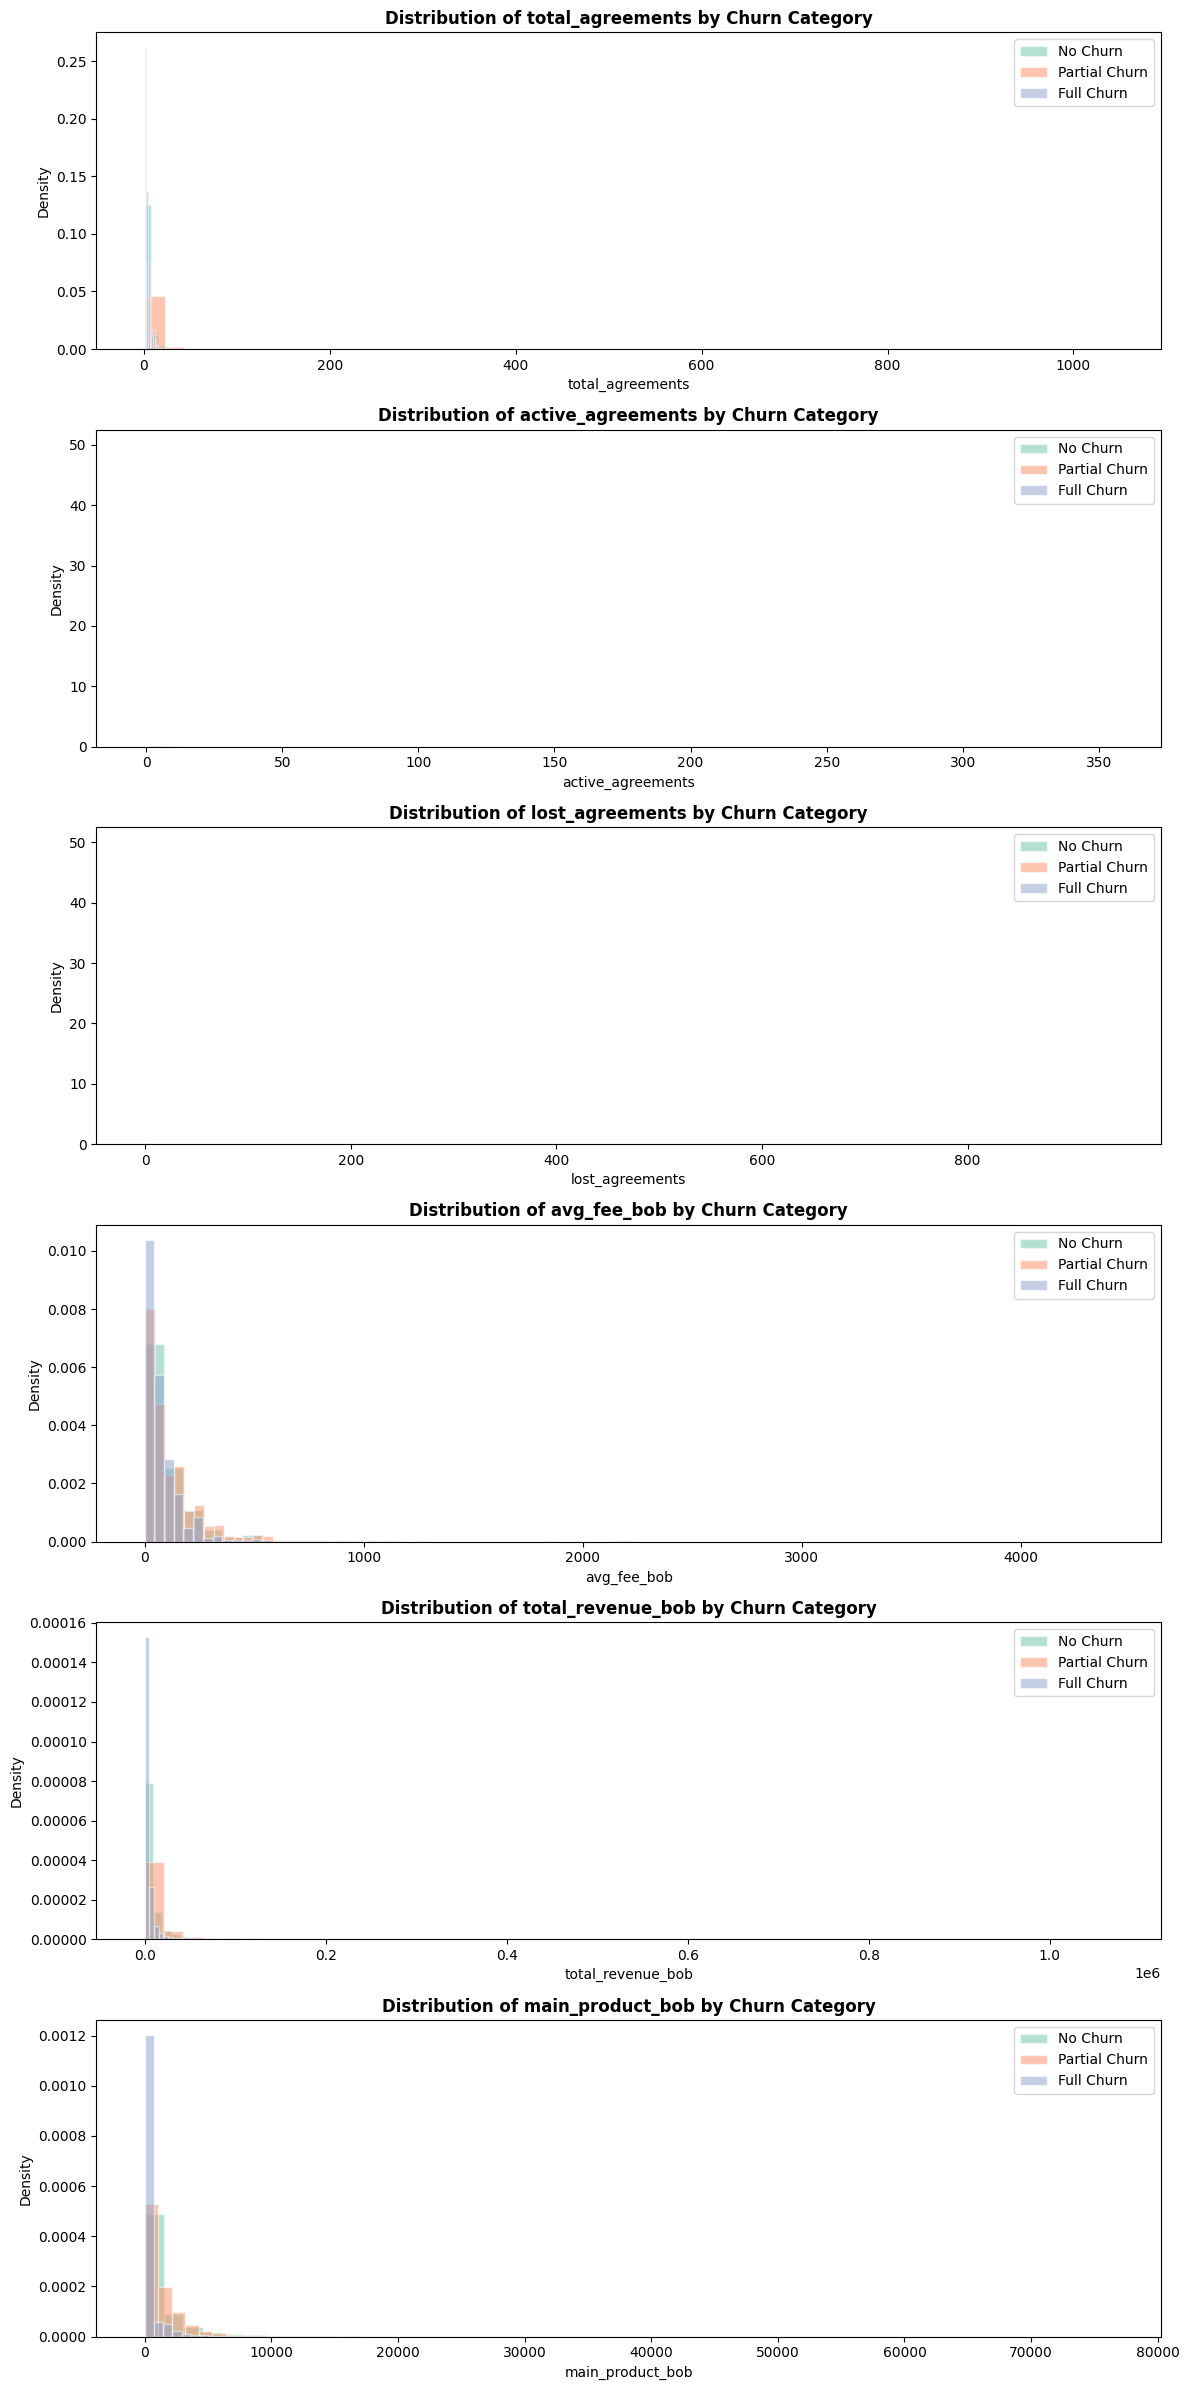

In [10]:
eda.plot_distributions(features=continuous_features)

### 4.2 Box Plots (Spread & Outliers by Churn Category)

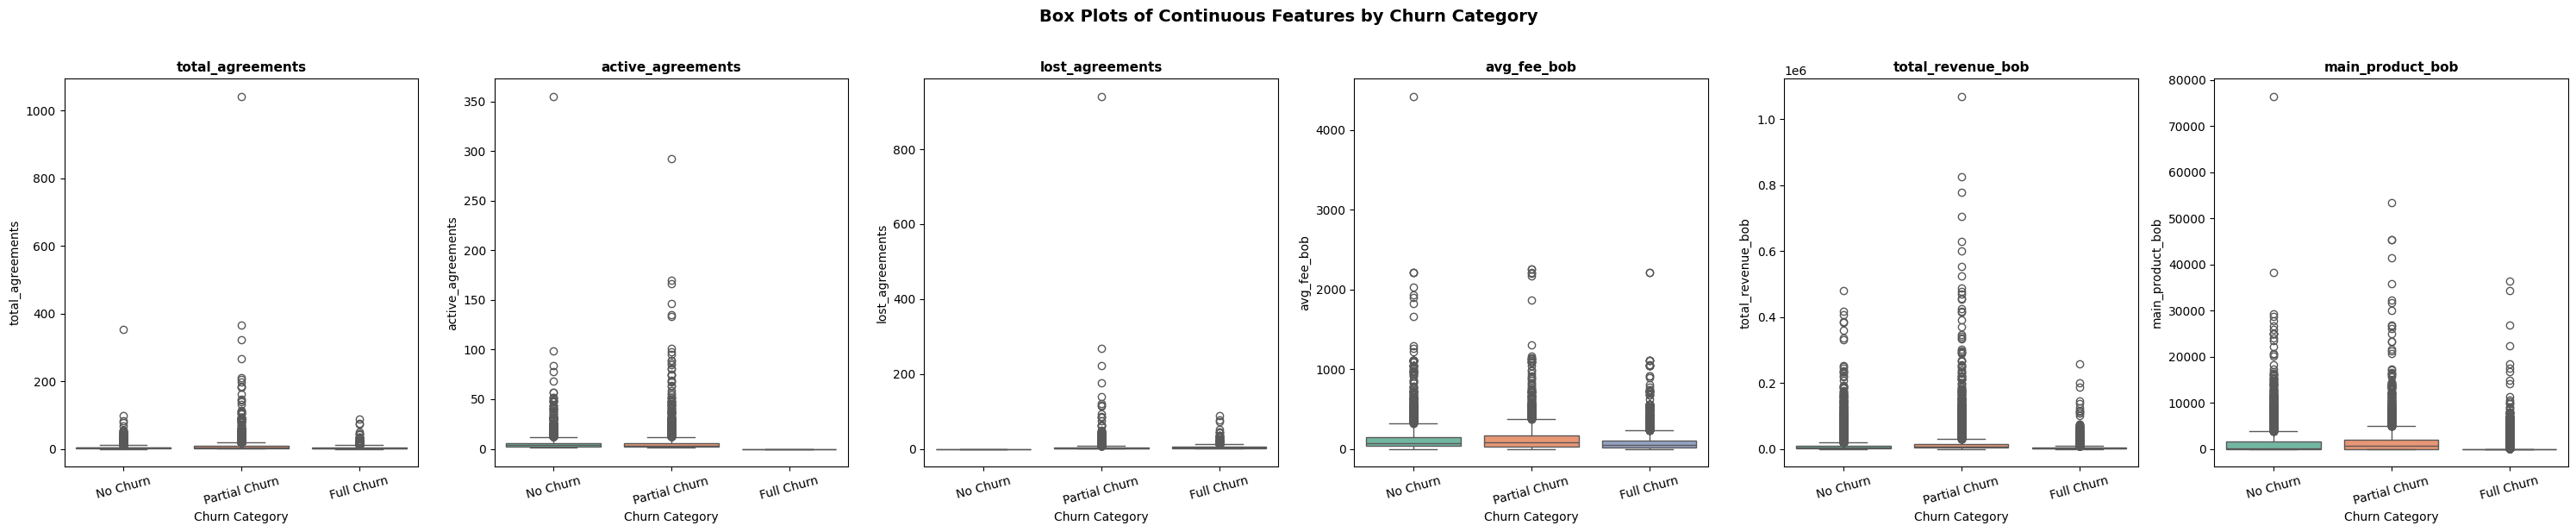

In [11]:
eda.plot_boxplots(features=continuous_features)

### 4.3 Density Plots (KDE by Churn Category)

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

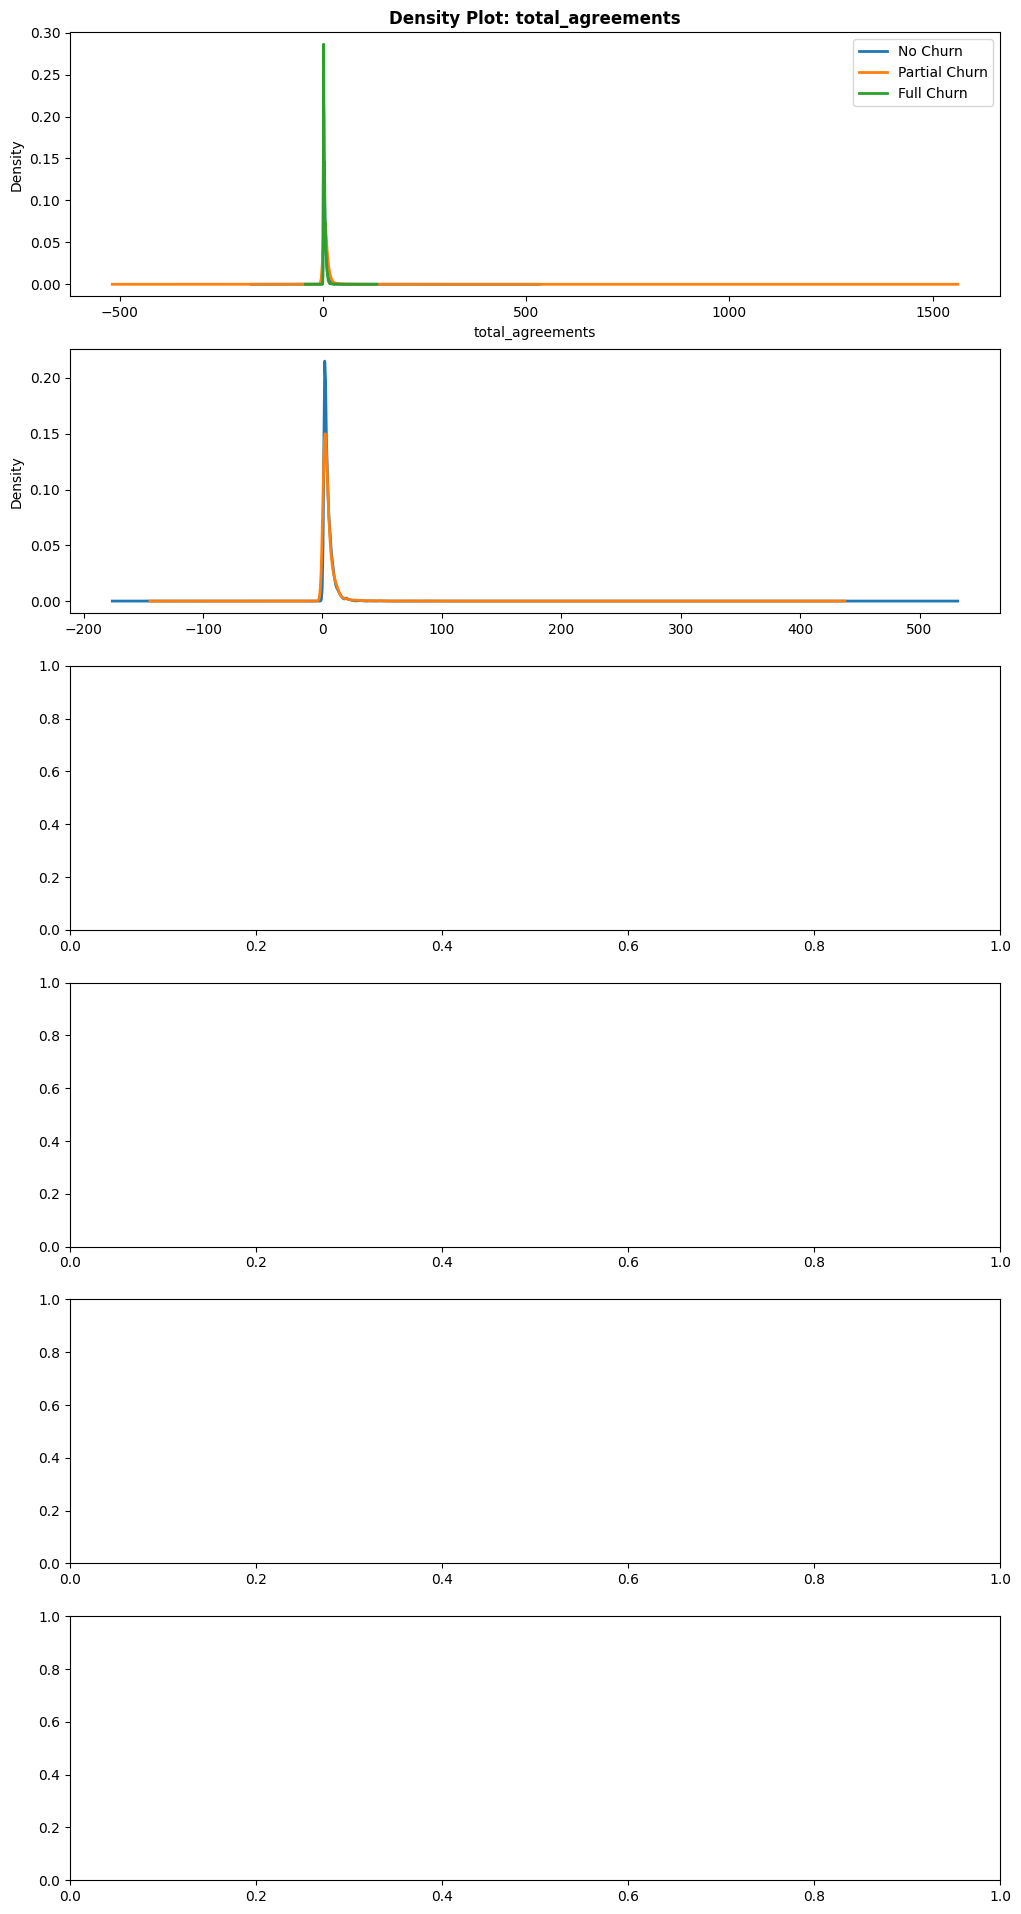

In [12]:
eda.plot_density(features=continuous_features)

### 4.4 Finding Outliers (IQR Method)

In [13]:
# Use the reusable OutlierDetection module
outlier_detector = outlier_module.OutlierDetection(analysis_df)
outlier_summary = outlier_detector.detect_outliers_iqr(features=continuous_features)

Outlier Detection Summary (IQR Method):
IQR Factor: 1.5
          Feature       Q1      Q3      IQR  Lower_Bound  Upper_Bound  Num_Outliers  Pct_Outliers  Total_Rows
 total_agreements    2.000    6.00    4.000      -4.0000      12.0000          1517          6.38       23772
active_agreements    0.000    4.00    4.000      -6.0000      10.0000          1272          5.35       23772
  lost_agreements    0.000    3.00    3.000      -4.5000       7.5000          1285          5.41       23772
      avg_fee_bob   27.540  138.12  110.580    -138.3300     303.9900          1404          5.91       23772
total_revenue_bob 1971.085 8948.64 6977.555   -8495.2475   19414.9725          2470         10.39       23772
 main_product_bob    0.000 1319.20 1319.200   -1978.8000    3298.0000          1943          8.17       23772


### 4.5 Correlation Heatmap

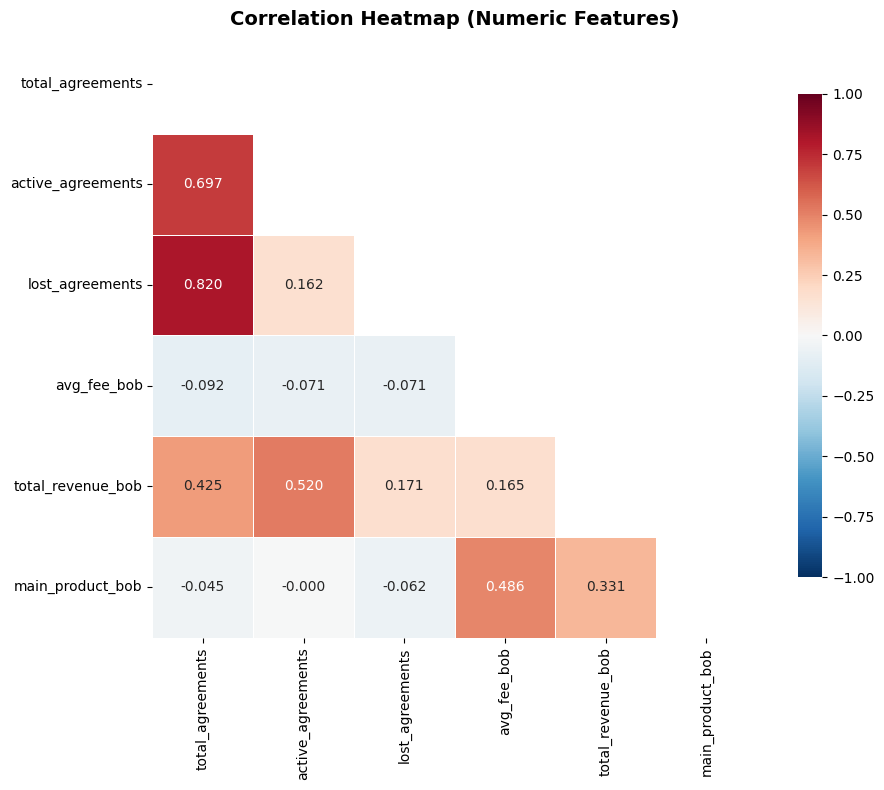

In [14]:
corr_matrix = eda.plot_correlation_heatmap(features=continuous_features)

### 4.6 Categorical Feature Distribution by Churn

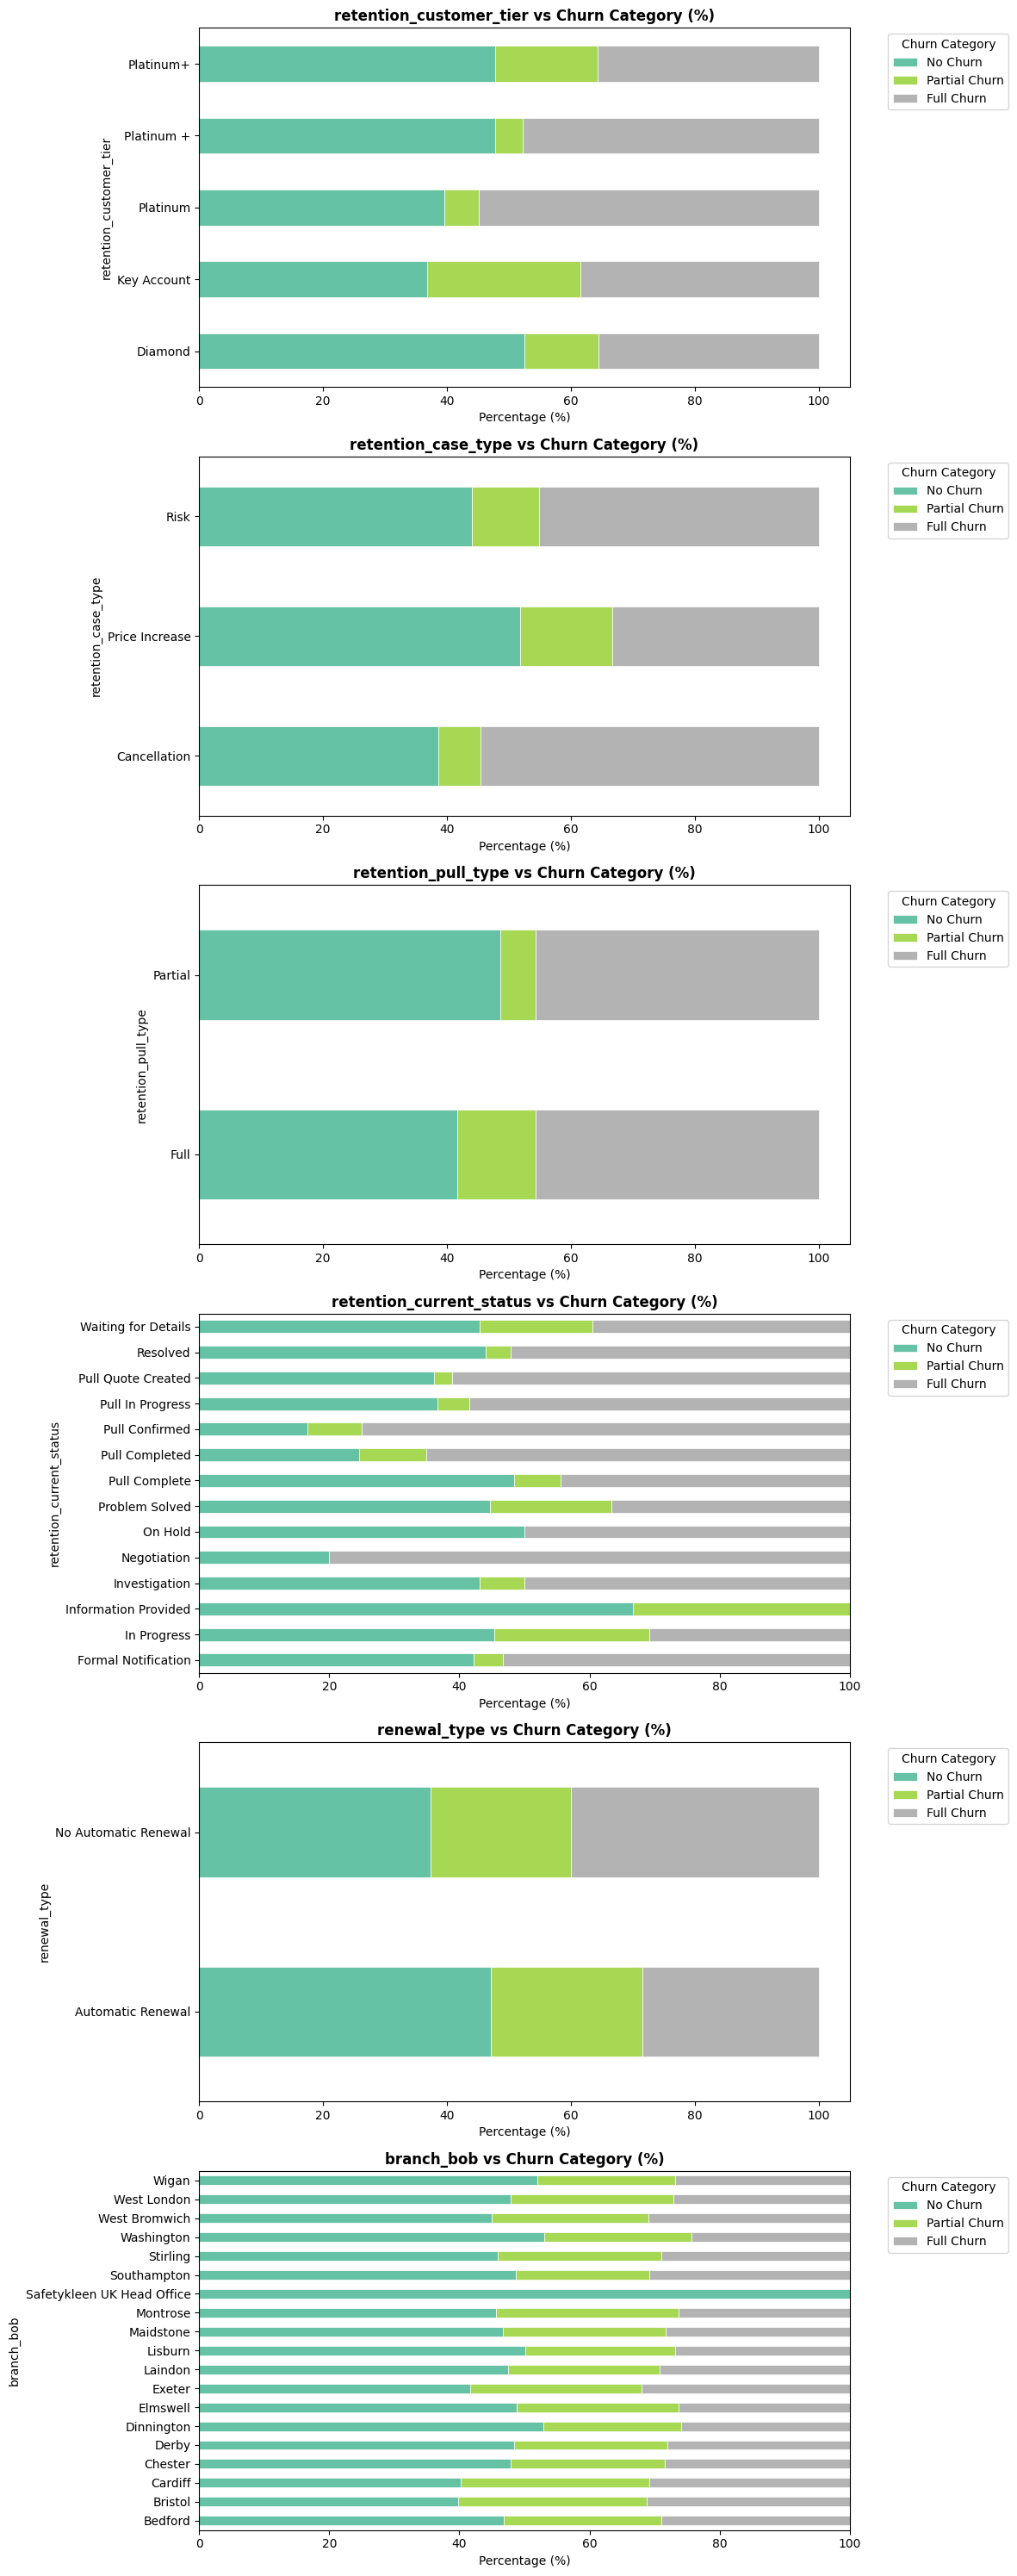

In [15]:
categorical_features = ['retention_customer_tier', 'retention_case_type',
                        'retention_pull_type', 'retention_current_status',
                        'renewal_type', 'branch_bob']
categorical_features = [f for f in categorical_features if f in analysis_df.columns]

eda.plot_categorical_bars(features=categorical_features)

---
# 5. Hypothesis Testing and Feature Selection

Based on the patterns observed in the EDA section, we now run statistical tests to **prove** our assumptions and determine which features actually impact churn.

- **Significance Level**: α = 0.05
- **Decision Rule**: If p-value < 0.05 → Reject H₀ (significant); else → Fail to reject H₀

In [16]:
# Initialize hypothesis results dictionary
hypothesis_results = {}

## Hypothesis 1: Categorical Independence (Chi-Square Test)

**Null Hypothesis (H₀)**: Categorical features are **independent** of churn category  
**Alternative Hypothesis (H₁)**: Categorical features are **dependent** on churn category  
**Significance Level**: α = 0.05

**Why this test?** Used for categorical variables to test if there's a significant association between the feature and the target variable. Assumptions: Random sampling, independence of observations, expected frequency ≥5 in at least 80% of cells.

In [17]:
# Run Hypothesis 1: Chi-Square Test
hypo_1_tester = hypo_1_module.Hypothesis1ChiSquare(analysis_df)
hypothesis_results['hypothesis_1'] = hypo_1_tester.run_test()

print('\nHypothesis 1 Results:')
df_1 = pd.DataFrame(hypothesis_results['hypothesis_1'])
display(df_1)

# Null Hypothesis Conclusion
print('\nNull Hypothesis Conclusion')
for _, row in df_1.iterrows():
    if row['Significant']:
        print(f"{row['Feature']}: REJECT H₀ (p={row['P-Value']:.2e}) → Feature IS dependent on churn")
    else:
        print(f"{row['Feature']}: FAIL TO REJECT H₀ (p={row['P-Value']:.2e}) → Feature is independent of churn")

Hypothesis 1: Categorical Independence (Chi-Square Test)
Null: Feature is independent of churn category
Alternative: Feature is dependent on churn category

Hypothesis 1 Results:


,Feature,Test,Statistic,P-Value,Significant
0,retention_customer_tier,Chi-Square,288.657599,1.066018e-57,True
1,retention_case_type,Chi-Square,54.383399,4.374377e-11,True
2,retention_pull_type,Chi-Square,24.394252,5.044935e-06,True
3,retention_current_status,Chi-Square,479.273412,6.662165e-85,True
4,retention_resolution_status,Chi-Square,305.006253,3.539888e-61,True
5,renewal_type,Chi-Square,7.734430,2.091654e-02,True



Null Hypothesis Conclusion
retention_customer_tier: REJECT H₀ (p=1.07e-57) → Feature IS dependent on churn
retention_case_type: REJECT H₀ (p=4.37e-11) → Feature IS dependent on churn
retention_pull_type: REJECT H₀ (p=5.04e-06) → Feature IS dependent on churn
retention_current_status: REJECT H₀ (p=6.66e-85) → Feature IS dependent on churn
retention_resolution_status: REJECT H₀ (p=3.54e-61) → Feature IS dependent on churn
renewal_type: REJECT H₀ (p=2.09e-02) → Feature IS dependent on churn


## Hypothesis 2: Difference in Means (ANOVA)

**Null Hypothesis (H₀)**: No difference in means of continuous features across churn categories  
**Alternative Hypothesis (H₁)**: Significant difference exists in means across churn categories  
**Significance Level**: α = 0.05

**Why this test?** Parametric test for comparing means across multiple groups. Assumptions: Normality, homoscedasticity, independence. Used when data meets parametric assumptions.

In [18]:
# Run Hypothesis 2: ANOVA
hypo_2_tester = hypo_2_module.Hypothesis2ANOVA(analysis_df)
hypothesis_results['hypothesis_2'] = hypo_2_tester.run_test()

print('\nHypothesis 2 Results:`')
df_2 = pd.DataFrame(hypothesis_results['hypothesis_2'])
display(df_2)

# Null Hypothesis Conclusion
print('\nNull Hypothesis Conclusion')
for _, row in df_2.iterrows():
    if row['Significant']:
        print(f"{row['Feature']}: REJECT H₀ (p={row['P-Value']:.2e}) → Means differ significantly across churn groups")
    else:
        print(f"{row['Feature']}: FAIL TO REJECT H₀ (p={row['P-Value']:.2e}) → No significant mean difference")

Hypothesis 2: Difference in Means (ANOVA)
Null: No significant difference in feature means across churn categories
Alternative: Significant difference exists

Hypothesis 2 Results:`


,Feature,Test,Statistic,P-Value,Significant
0,total_agreements,ANOVA,359.080621,2.305505e-154,True
1,active_agreements,ANOVA,1685.656465,0.000000e+00,True
2,lost_agreements,ANOVA,857.590956,0.000000e+00,True
3,avg_fee_bob,ANOVA,165.794125,3.119924e-72,True
4,total_revenue_bob,ANOVA,368.922385,1.642720e-158,True



Null Hypothesis Conclusion
total_agreements: REJECT H₀ (p=2.31e-154) → Means differ significantly across churn groups
active_agreements: REJECT H₀ (p=0.00e+00) → Means differ significantly across churn groups
lost_agreements: REJECT H₀ (p=0.00e+00) → Means differ significantly across churn groups
avg_fee_bob: REJECT H₀ (p=3.12e-72) → Means differ significantly across churn groups
total_revenue_bob: REJECT H₀ (p=1.64e-158) → Means differ significantly across churn groups


## Hypothesis 3: Non-parametric Difference (Permutation Test)

**Null Hypothesis (H₀)**: No difference in distributions of continuous features across churn categories  
**Alternative Hypothesis (H₁)**: Significant difference exists in distributions across churn categories  
**Significance Level**: α = 0.05

**Why this test?** Permutation tests are distribution-free and do not rely on normality assumptions. They compare the observed group statistic against randomized label permutations to validate feature differences robustly.

In [19]:
# Run Hypothesis 3: Permutation Test
hypo_3_tester = hypo_3_module.Hypothesis3PermutationTest(analysis_df)
hypothesis_results['hypothesis_3'] = hypo_3_tester.run_test()

print('\nHypothesis 3 Results:')
df_3 = pd.DataFrame(hypothesis_results['hypothesis_3'])
display(df_3)

# Null Hypothesis Conclusion
print('\nNull Hypothesis Conclusion')
for _, row in df_3.iterrows():
    if row['Significant']:
        print(f"{row['Feature']}: REJECT H₀ (p={row['P-Value']:.4f}) → Distributions differ significantly across churn groups")
    else:
        print(f"{row['Feature']}: FAIL TO REJECT H₀ (p={row['P-Value']:.4f}) → No significant distribution difference")

Hypothesis 3: Non-parametric Difference (Permutation Test)
Null: No significant difference in feature distributions across churn categories
Alternative: Significant difference exists

Hypothesis 3 Results:


,Feature,Test,Statistic,P-Value,Significant
0,total_agreements,Permutation ANOVA,359.080621,0.000999,True
1,active_agreements,Permutation ANOVA,1685.656465,0.000999,True
2,lost_agreements,Permutation ANOVA,857.590956,0.000999,True
3,avg_fee_bob,Permutation ANOVA,165.794125,0.000999,True
4,total_revenue_bob,Permutation ANOVA,368.922385,0.000999,True



Null Hypothesis Conclusion
total_agreements: REJECT H₀ (p=0.0010) → Distributions differ significantly across churn groups
active_agreements: REJECT H₀ (p=0.0010) → Distributions differ significantly across churn groups
lost_agreements: REJECT H₀ (p=0.0010) → Distributions differ significantly across churn groups
avg_fee_bob: REJECT H₀ (p=0.0010) → Distributions differ significantly across churn groups
total_revenue_bob: REJECT H₀ (p=0.0010) → Distributions differ significantly across churn groups


## Hypothesis 4: Normality Assumption (Q-Q Plot + Histogram + Skewness/Kurtosis)

**Null Hypothesis (H₀)**: Continuous features follow a normal distribution  
**Alternative Hypothesis (H₁)**: Continuous features do NOT follow a normal distribution  
**Method**: Q-Q Plots + Histograms + Skewness/Kurtosis thresholds

**Why this method?** Visual Q-Q plots and histograms are more intuitive and reliable for large datasets (N > 5000) than the Shapiro-Wilk test, which gives unreliable p-values for large sample sizes. Skewness (|skew| < 2) and Kurtosis (|kurt| < 7) thresholds provide numeric backup.

Hypothesis 4: Normality Assumption Check
Null (H₀): Feature follows a normal distribution
Alternative (H₁): Feature does NOT follow a normal distribution
Method: Q-Q Plots + Histograms + Skewness/Kurtosis



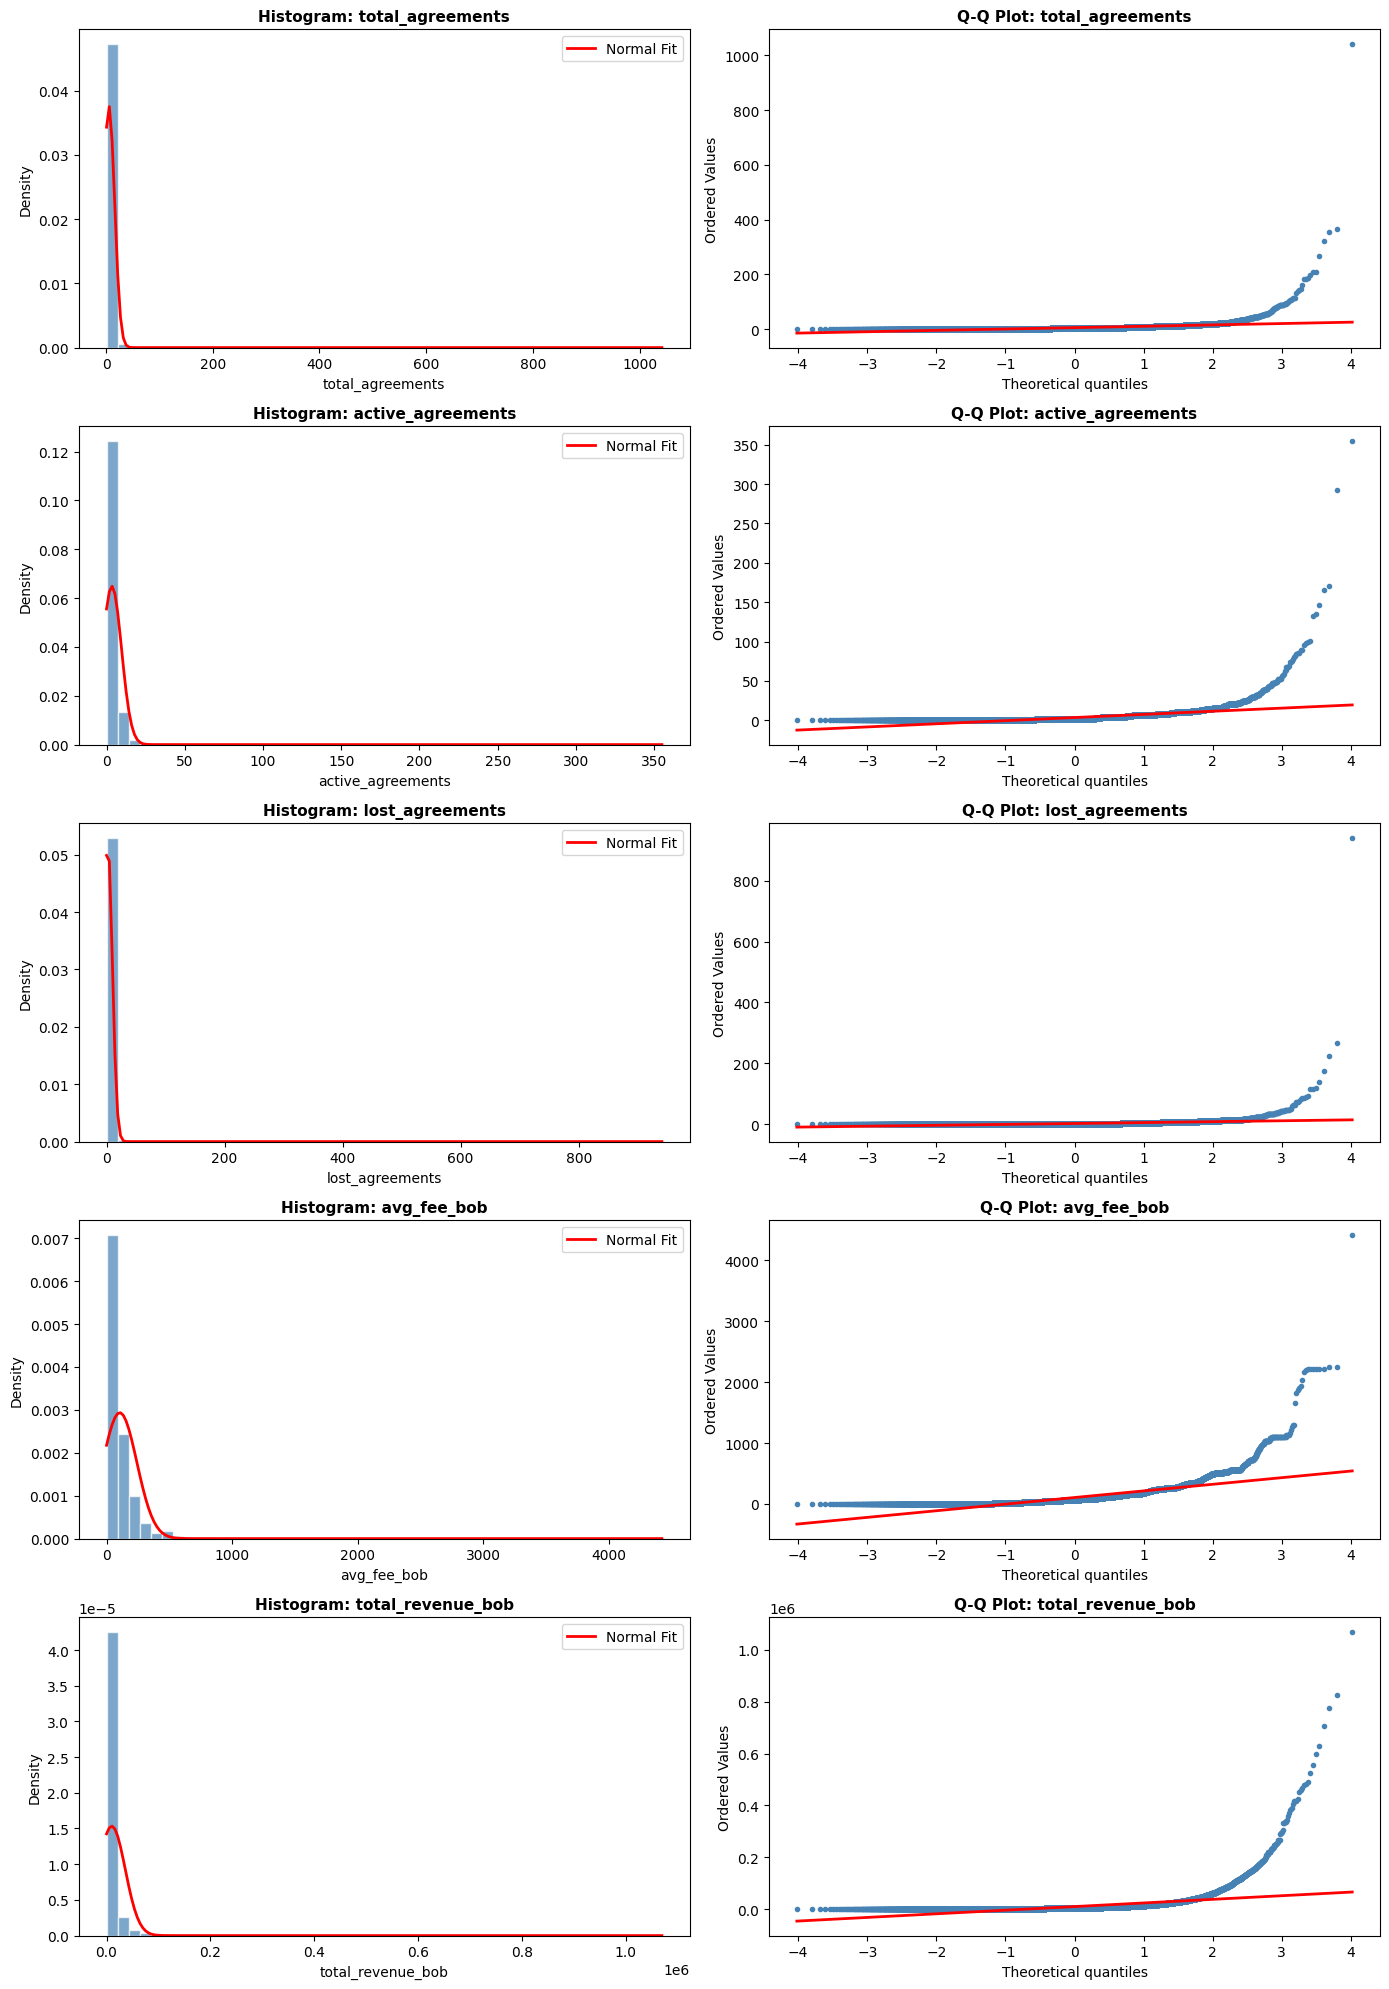


Hypothesis 4 Results:


,Feature,Test,Skewness,Kurtosis,Normal,Result
0,total_agreements,Skewness-Kurtosis + Q-Q Plot,47.3075,4032.8852,False,Reject H0
1,active_agreements,Skewness-Kurtosis + Q-Q Plot,18.3299,755.0469,False,Reject H0
2,lost_agreements,Skewness-Kurtosis + Q-Q Plot,80.8979,9407.0803,False,Reject H0
3,avg_fee_bob,Skewness-Kurtosis + Q-Q Plot,5.6789,83.2845,False,Reject H0
4,total_revenue_bob,Skewness-Kurtosis + Q-Q Plot,13.5651,315.5958,False,Reject H0



Null Hypothesis Conclusion
total_agreements: REJECT H₀ (Skew=47.307, Kurt=4032.885) → NOT normally distributed
active_agreements: REJECT H₀ (Skew=18.330, Kurt=755.047) → NOT normally distributed
lost_agreements: REJECT H₀ (Skew=80.898, Kurt=9407.080) → NOT normally distributed
avg_fee_bob: REJECT H₀ (Skew=5.679, Kurt=83.284) → NOT normally distributed
total_revenue_bob: REJECT H₀ (Skew=13.565, Kurt=315.596) → NOT normally distributed

Normality summary: 5 feature(s) reject H₀, 0 feature(s) fail to reject H₀.
→ Since most features are NOT normal, non-parametric tests (H3, H5) are more appropriate than ANOVA.


In [20]:
# Run Hypothesis 4: Normality Check (Q-Q Plot + Histogram + Skewness/Kurtosis)
hypo_4_tester = hypo_4_module.Hypothesis4Normality(analysis_df)
hypothesis_results['hypothesis_4'] = hypo_4_tester.run_test()

print('\nHypothesis 4 Results:')
df_4 = pd.DataFrame(hypothesis_results['hypothesis_4'])
display(df_4)

# Null Hypothesis Conclusion
print('\nNull Hypothesis Conclusion')
for _, row in df_4.iterrows():
    if row['Result'] == 'Reject H0':
        print(f"{row['Feature']}: REJECT H₀ (Skew={row['Skewness']:.3f}, Kurt={row['Kurtosis']:.3f}) → NOT normally distributed")
    else:
        print(f"{row['Feature']}: FAIL TO REJECT H₀ (Skew={row['Skewness']:.3f}, Kurt={row['Kurtosis']:.3f}) → Approximately normal")

num_reject = df_4[df_4['Result'] == 'Reject H0'].shape[0]
num_accept = df_4[df_4['Result'] == 'Fail to reject H0'].shape[0]
print(f'\nNormality summary: {num_reject} feature(s) reject H₀, {num_accept} feature(s) fail to reject H₀.')
if num_reject > 0:
    print('→ Since most features are NOT normal, non-parametric tests (H3, H5) are more appropriate than ANOVA.')

## Hypothesis 5: Homoscedasticity (Levene's Test)

**Null Hypothesis (H₀)**: Equal variances across churn categories for continuous features  
**Alternative Hypothesis (H₁)**: Unequal variances across churn categories  
**Significance Level**: α = 0.05

**Why this test?** Tests the homoscedasticity (equal variance) assumption required for ANOVA. Levene's test is more robust than Bartlett's test against departures from normality.

In [21]:
# Run Hypothesis 5: Levene's Homoscedasticity Test
hypo_5_tester = hypo_5_module.Hypothesis5Homoscedasticity(analysis_df)
hypothesis_results['hypothesis_5'] = hypo_5_tester.run_test()

print('\nHypothesis 5 Results:')
df_5 = pd.DataFrame(hypothesis_results['hypothesis_5'])
display(df_5)

# Null Hypothesis Conclusion
print('\nNull Hypothesis Conclusion')
for _, row in df_5.iterrows():
    if row['Equal_Variance']:
        print(f"{row['Feature']}: FAIL TO REJECT H₀ (p={row['P-Value']:.2e}) → Equal variances (homoscedastic)")
    else:
        print(f"{row['Feature']}: REJECT H₀ (p={row['P-Value']:.2e}) → Unequal variances (heteroscedastic)")

num_hetero = df_5[~df_5['Equal_Variance']].shape[0]
if num_hetero > 0:
    print(f'\n→ {num_hetero} feature(s) violate homoscedasticity, further validating the use of non-parametric tests.')

Hypothesis 5: Homoscedasticity (Levene's Test)
Null: Equal variances across churn categories
Alternative: Unequal variances across churn categories

Hypothesis 5 Results:


,Feature,Test,Statistic,P-Value,Equal_Variance
0,total_agreements,Levene,188.326081,7.116810e-82,False
1,active_agreements,Levene,711.632278,6.942717e-301,False
2,lost_agreements,Levene,288.041934,2.493846e-124,False
3,avg_fee_bob,Levene,134.197916,1.109639e-58,False
4,total_revenue_bob,Levene,254.642019,3.788685e-110,False



Null Hypothesis Conclusion
total_agreements: REJECT H₀ (p=7.12e-82) → Unequal variances (heteroscedastic)
active_agreements: REJECT H₀ (p=6.94e-301) → Unequal variances (heteroscedastic)
lost_agreements: REJECT H₀ (p=2.49e-124) → Unequal variances (heteroscedastic)
avg_fee_bob: REJECT H₀ (p=1.11e-58) → Unequal variances (heteroscedastic)
total_revenue_bob: REJECT H₀ (p=3.79e-110) → Unequal variances (heteroscedastic)

→ 5 feature(s) violate homoscedasticity, further validating the use of non-parametric tests.


## Hypothesis 6: Correlation Analysis (Pearson & Spearman)

**Null Hypothesis (H₀)**: No linear/monotonic correlation between continuous features and churn  
**Alternative Hypothesis (H₁)**: Significant correlation exists between features and churn  
**Significance Level**: α = 0.05

**Why this test?** Measures strength and direction of the relationship. Pearson for linear, Spearman for monotonic. Used to identify features with strong relationships to the target.

In [22]:
# Run Hypothesis 6: Correlation Analysis
hypo_6_tester = hypo_6_module.Hypothesis6Correlation(analysis_df)
hypothesis_results['hypothesis_6'] = hypo_6_tester.run_test()

print('\nHypothesis 6 Results:')
df_6 = pd.DataFrame(hypothesis_results['hypothesis_6'])
display(df_6)

# Null Hypothesis Conclusion
print('\nNull Hypothesis Conclusion:')
for _, row in df_6.iterrows():
    spearman_sig = row['Spearman_P'] < 0.05
    pearson_sig = row['Pearson_P'] < 0.05
    if spearman_sig or pearson_sig:
        strength = 'Strong' if abs(row['Spearman_Corr']) > 0.5 else ('Moderate' if abs(row['Spearman_Corr']) > 0.3 else 'Weak')
        direction = 'positive' if row['Spearman_Corr'] > 0 else 'negative'
        print(f"{row['Feature']}: REJECT H₀ → {strength} {direction} correlation (Spearman={row['Spearman_Corr']:.3f})")
    else:
        print(f"{row['Feature']}: FAIL TO REJECT H₀ → No significant correlation")

Hypothesis 6: Correlation Analysis
Null: No correlation between feature and churn
Alternative: Significant correlation exists

Hypothesis 6 Results:


,Feature,Pearson_Corr,Pearson_P,Spearman_Corr,Spearman_P
0,total_agreements,0.001265,8.453194e-01,0.031682,1.030167e-06
1,active_agreements,-0.302139,0.000000e+00,-0.700711,0.000000e+00
2,lost_agreements,0.242985,1.629943e-316,0.895444,0.000000e+00
3,avg_fee_bob,-0.092167,5.172634e-46,-0.103877,4.980926e-58
4,total_revenue_bob,-0.063025,2.326824e-22,-0.134050,9.821363e-96



Null Hypothesis Conclusion:
total_agreements: REJECT H₀ → Weak positive correlation (Spearman=0.032)
active_agreements: REJECT H₀ → Strong negative correlation (Spearman=-0.701)
lost_agreements: REJECT H₀ → Strong positive correlation (Spearman=0.895)
avg_fee_bob: REJECT H₀ → Weak negative correlation (Spearman=-0.104)
total_revenue_bob: REJECT H₀ → Weak negative correlation (Spearman=-0.134)


## Hypothesis 7: Multicollinearity Check (VIF)

**Null Hypothesis (H₀)**: No multicollinearity among continuous features (VIF ≤ 5)  
**Alternative Hypothesis (H₁)**: Multicollinearity exists among features (VIF > 5)  
**Threshold**: VIF > 5 indicates potential multicollinearity issues

**Why this test?** Detects multicollinearity in regression models. VIF > 5-10 indicates problematic multicollinearity. Used to ensure feature independence in modeling.

> **Note**: `total_agreements = active_agreements + lost_agreements` creates **perfect collinearity** (VIF = ∞). This is expected and `total_agreements` should be dropped in feature selection.

In [23]:
# Run Hypothesis 7: Multicollinearity Check (VIF)
hypo_7_tester = hypo_7_module.Hypothesis7Multicollinearity(analysis_df)
hypothesis_results['hypothesis_7'] = hypo_7_tester.run_test()

print('\nHypothesis 7 Results:')
df_7 = pd.DataFrame(hypothesis_results['hypothesis_7'])
display(df_7)

# Null Hypothesis Conclusion
print('\nNull Hypothesis Conclusion:')
for _, row in df_7.iterrows():
    vif_str = f'{row["VIF"]:.3f}' if not np.isinf(row['VIF']) else '∞'
    if row['Result'] == 'Reject H0':
        print(f"{row['Feature']}: REJECT H₀ (VIF={vif_str}) → {row['Notes']}")
    else:
        print(f"{row['Feature']}: FAIL TO REJECT H₀ (VIF={vif_str}) → {row['Notes']}")

num_problematic = df_7[df_7['Problematic']].shape[0]
if num_problematic > 0:
    print(f'\n{num_problematic} feature(s) show multicollinearity. Recommendation: Drop total_agreements (derived feature).')

Hypothesis 7: Multicollinearity Check (VIF)
Null (H₀): No multicollinearity among continuous predictors (VIF ≤ 5)
Alternative (H₁): Multicollinearity exists (VIF > 5)

Hypothesis 7 Results:


,Feature,VIF,Problematic,Result,Notes
0,total_agreements,inf,True,Reject H0,Perfect collinearity detected (total = active ...
1,active_agreements,inf,True,Reject H0,Perfect collinearity detected (total = active ...
2,lost_agreements,inf,True,Reject H0,Perfect collinearity detected (total = active ...
3,avg_fee_bob,1.0729,False,Fail to reject H0,No multicollinearity concern
4,total_revenue_bob,1.4728,False,Fail to reject H0,No multicollinearity concern



Null Hypothesis Conclusion:
total_agreements: REJECT H₀ (VIF=∞) → Perfect collinearity detected (total = active + lost)
active_agreements: REJECT H₀ (VIF=∞) → Perfect collinearity detected (total = active + lost)
lost_agreements: REJECT H₀ (VIF=∞) → Perfect collinearity detected (total = active + lost)
avg_fee_bob: FAIL TO REJECT H₀ (VIF=1.073) → No multicollinearity concern
total_revenue_bob: FAIL TO REJECT H₀ (VIF=1.473) → No multicollinearity concern

3 feature(s) show multicollinearity. Recommendation: Drop total_agreements (derived feature).


---
# 6. Creating Churn Category Numeric Labels

Encoding the churn target variable numerically for downstream modeling:
- **0** = No Churn (Active)
- **1** = Partial Churn (Agreement-level)
- **2** = Full Churn (Customer-level)

In [24]:
# Create numeric churn labels
churn_map = {'No Churn': 0, 'Partial Churn': 1, 'Full Churn': 2}
analysis_df['churn_label'] = analysis_df['churn_category'].map(churn_map)

print('Churn Category Encoding:')
print('  0 = No Churn (Active customer)')
print('  1 = Partial Churn (Agreement-level / some agreements lost)')
print('  2 = Full Churn (Customer-level / all agreements lost)')
print(f'\nChurn label distribution:')
print(analysis_df['churn_label'].value_counts().sort_index())
print(f'\nChurn label distribution (%):')
print((analysis_df['churn_label'].value_counts(normalize=True).sort_index() * 100).round(2))

Churn Category Encoding:
  0 = No Churn (Active customer)
  1 = Partial Churn (Agreement-level / some agreements lost)
  2 = Full Churn (Customer-level / all agreements lost)

Churn label distribution:
churn_label
0    11181
1     5802
2     6789
Name: count, dtype: int64

Churn label distribution (%):
churn_label
0    47.03
1    24.41
2    28.56
Name: proportion, dtype: float64


---
# 7. Feature Selection Summary

Final list of encoded, scaled, and statistically proven features to keep for the modeling stage. Dropping features that showed no correlation or failed hypothesis tests.

In [25]:
# Generate Feature Selection Summary using the reusable module
summary_generator = summary_module.FeatureSelectionSummary(hypothesis_results, analysis_df)
summary_results = summary_generator.generate_summary()

Generating Feature Selection Summary...

SIGNIFICANT FEATURES IDENTIFIED (11 features):
  1. retention_pull_type
  2. active_agreements
  3. retention_current_status
  4. avg_fee_bob
  5. retention_customer_tier
  6. retention_resolution_status
  7. total_agreements
  8. renewal_type
  9. total_revenue_bob
  10. lost_agreements
  11. retention_case_type

FEATURE SUMMARY TABLE
                    Feature        Type
        retention_pull_type Categorical
          active_agreements  Continuous
   retention_current_status Categorical
                avg_fee_bob  Continuous
    retention_customer_tier Categorical
retention_resolution_status Categorical
           total_agreements  Continuous
               renewal_type Categorical
          total_revenue_bob  Continuous
            lost_agreements  Continuous
        retention_case_type Categorical

DATA READY FOR MODELING STAGE
Final dataset shape: (23772, 17)
Target variable (Churn Category) distribution:
churn_category
No Churn       

### Recommendation: Features to Drop

Based on hypothesis testing results:
1. **`total_agreements`** — Perfect multicollinearity (VIF = ∞), since `total = active + lost`
2. **`account_number`** — Identifier, not a feature
3. **`retention_country`** — Low variance (mostly UK)
4. **`retention_resolution_status`** — Directly derived from churn logic (data leakage risk)

---
## Key Insights

### Churn Category Distribution
- **No Churn (~47%)**: Customers maintained all active agreements
- **Full Churn (~29%)**: Customers lost all agreements (highest risk)
- **Partial Churn (~24%)**: Customers lost some agreements but kept others

### Statistical Findings
- **All categorical features** (customer tier, case type, pull type, status, renewal type) showed **significant association** with churn (H1: Chi-Square p < 0.001)
- **All continuous features** showed **significant mean differences** across churn groups (H2: ANOVA p < 0.001), confirmed by non-parametric permutation test (H3)
- **No feature** was normally distributed (H4), and **all** showed unequal variances (H5) — validating the use of non-parametric tests
- **`active_agreements`** and **`lost_agreements`** are the strongest predictors with Spearman correlations of ~-0.70 and ~0.90 respectively
- **`total_agreements`** should be dropped due to perfect multicollinearity (VIF = ∞)

### Data Ready for Gold Layer
The analysis dataset with identified significant features is now ready for model building (Gold Layer).